In [1]:
# ==============================================================================
# 1. Importacion de Librerias y Carga del Modelo
# ==============================================================================
import pandas as pd
import numpy as np
import joblib
import os

print("Preparando entorno de Virtual Screening...")

# Cargar el modelo guardado desde el Cuaderno 02
ruta_modelo = "../models/best_rf_pampa.pkl"

try:
    best_rf = joblib.load(ruta_modelo)
    print(f" Modelo Random Forest cargado exitosamente.")
    
    # Extraer los nombres exactos de las 11 variables que el modelo exige
    features_modelo = best_rf.feature_names_in_
    print(f" El modelo requiere exactamente estas {len(features_modelo)} variables:")
    print(list(features_modelo))
    
except FileNotFoundError:
    print(f" ERROR: No se encontro el modelo en {ruta_modelo}.")

Preparando entorno de Virtual Screening...
 Modelo Random Forest cargado exitosamente.
 El modelo requiere exactamente estas 11 variables:
['LOGPcons', 'MACCSFP125', 'PCR', 'Psi_e_A', 'P_VSA_ppp_D', 'Mp', 'SpMin1_Bh(p)', 'SHED_AL', 'SM12_AEA(ri)', 'P_VSA_s_3', 'MATS5m']


In [ ]:
# ==============================================================================
# 2. Motor Central de Cribado Virtual
# ==============================================================================

def ejecutar_cribado(file_desc, file_fing, archivo_salida):
    """
    Toma los descriptores, fingerprints, los cruza, filtra las 11 variables,
    predice la probabilidad con el modelo y guarda un CSV limpio.
    """
    print(f"Iniciando procesamiento para: {os.path.basename(archivo_salida)}")
    
    try:
        # 1. Carga y limpieza
        df_d = pd.read_csv(file_desc, sep='\t')
        df_f = pd.read_csv(file_fing, sep='\t')
        
        if 'NAME' in df_d.columns: df_d['NAME'] = df_d['NAME'].astype(str).str.strip()
        if 'NAME' in df_f.columns: df_f['NAME'] = df_f['NAME'].astype(str).str.strip()
        
        # 2. Fusion
        df_total = pd.merge(df_d, df_f, on='NAME', how='inner')
        print(f"   -> Fusión correcta: {len(df_total)} moléculas encontradas.")
        
        # 3. Filtrado de las 11 variables
        X_input = pd.DataFrame()
        for col in features_modelo:
            if col in df_total.columns:
                X_input[col] = df_total[col]
            else:
                X_input[col] = 0 # Relleno de seguridad
                
        # Limpiar infinitos y nulos
        X_input = X_input.fillna(0).replace([np.inf, -np.inf], 0)
        
        # 4. Prediccion
        probs = best_rf.predict_proba(X_input)[:, 1]
        
        # 5. Construccion del DataFrame Final
        df_final = df_total[['NAME']].copy()
        df_final = df_final.rename(columns={'NAME': 'ID_Molecula'})
        df_final['Probabilidad_Permeable'] = probs
        
        # Agregamos las 11 variables para el reporte
        for col in features_modelo:
            df_final[col] = X_input[col]
            
        # Ordenar de mayor a menor probabilidad
        df_final = df_final.sort_values(by='Probabilidad_Permeable', ascending=False)
        
        # 6. Guardado
        os.makedirs(os.path.dirname(archivo_salida), exist_ok=True)
        df_final.to_csv(archivo_salida, index=False)
        print(f"Archivo guardado: {archivo_salida}")
        
        return df_final

    except Exception as e:
        print(f" Error en el proceso: {e}")
        return None

In [4]:
# ==============================================================================
# 3. Ejecucion de las Fases de Cribado
# ==============================================================================

# FASE 1: PRE-CRIBADO (Las 5 moléculas de prueba)
# Nota: Asegúrate de que estas rutas sean correctas en tu PC
ruta_desc_5 = r"C:\Users\benja\Desktop\QSAR\calculos-screeningg.txt"
ruta_fing_5 = r"C:\Users\benja\Desktop\QSAR\calculos-screening-fingerr.txt"
salida_5 = "../results/screening/Pre_Cribado_5_Moleculas.csv"

df_precribado = ejecutar_cribado(ruta_desc_5, ruta_fing_5, salida_5)

if df_precribado is not None:
    print("\nVista previa del Pre-Cribado (Top 5):")
    display(df_precribado[['ID_Molecula', 'Probabilidad_Permeable', 'LOGPcons', 'MACCSFP125']].head())

print("-" * 60)

# FASE 2: CRIBADO MASIVO (La base de datos completa)
# Nota: Cambia estas rutas por los archivos que tienen la base de datos grande
ruta_desc_masivo = r"C:\Users\benja\Desktop\QSAR\calculos-screening.txt"
ruta_fing_masivo = r"C:\Users\benja\Desktop\QSAR\calculos-screening-finger.txt"
salida_masivo = "../results/screening/Candidatos_Masivos_PAMPA.csv"

df_masivo = ejecutar_cribado(ruta_desc_masivo, ruta_fing_masivo, salida_masivo)

if df_masivo is not None:
    print("\nVista previa del Cribado Masivo (Top 10):")
    display(df_masivo[['ID_Molecula', 'Probabilidad_Permeable', 'LOGPcons', 'MACCSFP125']].head(10))

Iniciando procesamiento para: Pre_Cribado_5_Moleculas.csv
   -> Fusión correcta: 5 moléculas encontradas.
   💾 Archivo guardado: ../results/screening/Pre_Cribado_5_Moleculas.csv

Vista previa del Pre-Cribado (Top 5):


,ID_Molecula,Probabilidad_Permeable,LOGPcons,MACCSFP125
2,Molecule3,0.696284,5.3190,1
1,Molecule2,0.694790,4.8610,1
3,Molecule4,0.659033,4.1490,1
0,Molecule1,0.647800,4.8610,1
4,Molecule5,0.045020,1.3086,0


------------------------------------------------------------
Iniciando procesamiento para: Candidatos_Masivos_PAMPA.csv
   -> Fusión correcta: 34 moléculas encontradas.
   💾 Archivo guardado: ../results/screening/Candidatos_Masivos_PAMPA.csv

Vista previa del Cribado Masivo (Top 10):


,ID_Molecula,Probabilidad_Permeable,LOGPcons,MACCSFP125
8,Molecule9,0.529873,3.9101,0
17,Molecule18,0.482630,3.9401,0
31,Molecule32,0.457866,2.9635,0
9,Molecule10,0.445853,3.8173,0
7,Molecule8,0.413670,2.7299,0
6,Molecule7,0.413670,2.7299,0
32,Molecule33,0.363297,2.7719,0
19,Molecule20,0.360669,2.7978,0
10,Molecule11,0.355613,2.7948,0
30,Molecule31,0.354328,2.5910,0


Inicializando modulo de Quimioinformatica y cruce de datos...
STATUS: Traductor cargado. 4848 equivalencias registradas.
STATUS: Analisis SDF completado. 4845 estructuras indexadas.

--- Resultados del Filtro de Lipinski ---


,DrugBank_ID,Probabilidad,MW,LogP_RDKit,HBD,HBA,Aprobado_Lipinski
0,DB00117,0.696284,155.16,-0.64,3,3,SI
1,DB00116,0.694790,445.44,-0.28,8,9,SI
2,DB00118,0.659033,399.45,-1.92,5,10,SI
3,DB00114,0.647800,247.14,0.52,3,5,SI
4,DB00119,0.045020,88.06,-0.34,1,2,SI



--- Renderizado Estructural 2D ---


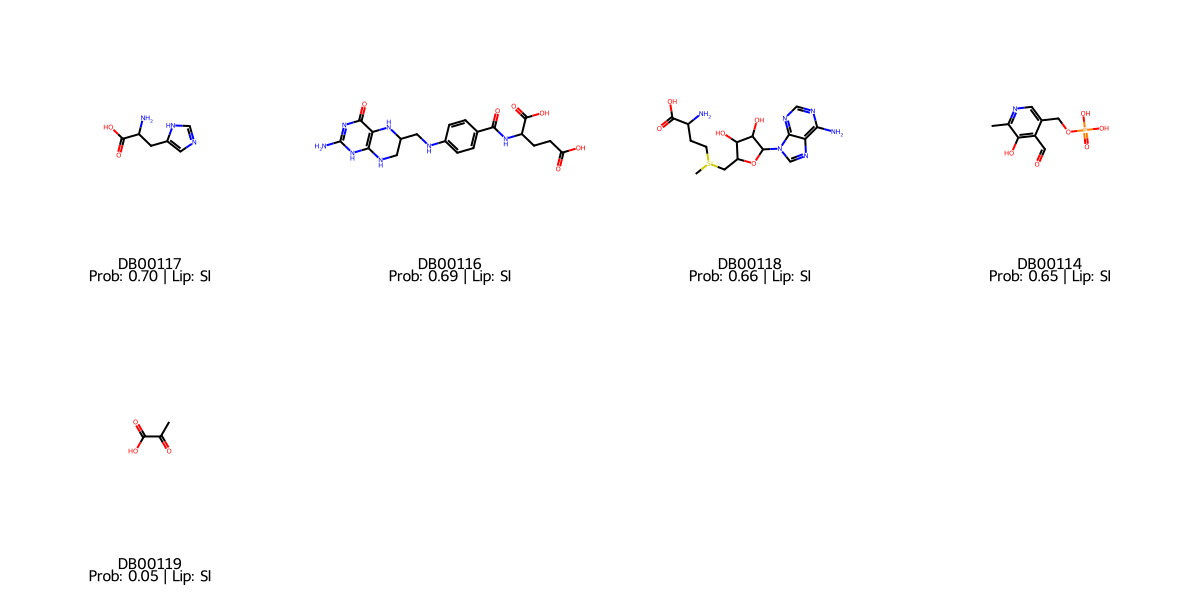

STATUS: Galeria exportada a ../results/figures/Galeria_Top_Candidatos.png


In [7]:
# ==============================================================================
# 4. Evaluacion de Drogabilidad (Lipinski) y Visualizacion Estructural 2D
# ==============================================================================
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem
from IPython.display import display
import os

print("Inicializando modulo de Quimioinformatica y cruce de datos...")

# 1. Configurar rutas
# Ajusta las rutas segun donde tengas descargados los archivos
archivo_resultados = "../results/screening/Pre_Cribado_5_Moleculas.csv" 
archivo_SDF = r"C:\Users\benja\Desktop\QSAR\allCOR3D.sdf"
archivo_traductor = r"C:\Users\benja\Desktop\QSAR\Lista_DrugBank_IDs.csv"

df_hits = pd.read_csv(archivo_resultados)

# 2. Crear el "Traductor" de nombres (MoleculeX -> DBXXXXX)
dicc_traductor = {}
try:
    df_nombres = pd.read_csv(archivo_traductor)
    for _, row in df_nombres.iterrows():
        nombre_falso = f"Molecule{int(row['Orden'])}"
        nombre_real = str(row['DrugBank_ID']).strip()
        dicc_traductor[nombre_falso] = nombre_real
    print(f"STATUS: Traductor cargado. {len(dicc_traductor)} equivalencias registradas.")
except FileNotFoundError:
    print(f"ERROR: No se encontro el archivo traductor en: {archivo_traductor}")

# 3. Extraer SMILES del archivo SDF
dicc_smiles = {}
try:
    with open(archivo_SDF, 'r', encoding='utf-8', errors='ignore') as f:
        bloques = f.read().split("$$$$")
        for bloque in bloques:
            lines = bloque.split('\n')
            curr_id, curr_smi = None, None
            
            for j, line in enumerate(lines):
                if "> <DRUGBANK_ID>" in line: 
                    curr_id = lines[j+1].strip()
                if "> <DRUGBANK_CANONICAL_SMILES>" in line:
                    curr_smi = lines[j+1].strip()
            
            if curr_id and curr_smi:
                dicc_smiles[curr_id] = curr_smi
    print(f"STATUS: Analisis SDF completado. {len(dicc_smiles)} estructuras indexadas.")
except FileNotFoundError:
    print(f"ERROR: No se encontro el archivo SDF en: {archivo_SDF}")

# 4. Analisis Fisicoquimico de Candidatos
resultados_quimicos = []
mols_dibujo = []
leyendas = []

for idx, row in df_hits.iterrows():
    id_falso = str(row['ID_Molecula'])
    prob = row['Probabilidad_Permeable']
    
    # 4.1 Traducir ID
    id_real = dicc_traductor.get(id_falso, id_falso) 
    
    # 4.2 Buscar SMILES con el ID real
    smi = dicc_smiles.get(id_real, None)
    
    if smi:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            # Calcular parametros
            mw = Descriptors.MolWt(mol)
            logp = Descriptors.MolLogP(mol)
            hbd = Descriptors.NumHDonors(mol)
            hba = Descriptors.NumHAcceptors(mol)
            
            violaciones = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
            es_drogable = "SI" if violaciones <= 1 else "NO"
            
            resultados_quimicos.append({
                'ID_Original': id_falso,
                'DrugBank_ID': id_real,
                'Probabilidad': prob,
                'MW': round(mw, 2),
                'LogP_RDKit': round(logp, 2),
                'HBD': hbd,
                'HBA': hba,
                'Violaciones_Lipinski': violaciones,
                'Aprobado_Lipinski': es_drogable
            })
            
            # Preparar visualizacion 2D
            AllChem.Compute2DCoords(mol)
            leyenda = f"{id_real}\nProb: {prob:.2f} | Lip: {es_drogable}"
            mol.SetProp("_Name", leyenda)
            mols_dibujo.append(mol)
            leyendas.append(leyenda)
    else:
        print(f"ADVERTENCIA: La estructura para '{id_real}' (originalmente {id_falso}) no se encontro en el SDF.")

# 5. Reporte Final y Graficacion
if resultados_quimicos:
    df_lipinski = pd.DataFrame(resultados_quimicos)
    print("\n--- Resultados del Filtro de Lipinski ---")
    display(df_lipinski[['DrugBank_ID', 'Probabilidad', 'MW', 'LogP_RDKit', 'HBD', 'HBA', 'Aprobado_Lipinski']])
    
    # Exportar
    ruta_reporte = "../results/screening/Reporte_Lipinski_Candidatos.csv"
    os.makedirs(os.path.dirname(ruta_reporte), exist_ok=True)
    df_lipinski.to_csv(ruta_reporte, index=False)
    
    if len(mols_dibujo) > 0:
        print("\n--- Renderizado Estructural 2D ---")
        img_grid = Draw.MolsToGridImage(
            mols_dibujo,
            molsPerRow=4,
            subImgSize=(300, 300),
            legends=leyendas,
            returnPNG=False 
        )
        display(img_grid)
        
        ruta_imagen = "../results/figures/Galeria_Top_Candidatos.png"
        img_grid.save(ruta_imagen)
        print(f"STATUS: Galeria exportada a {ruta_imagen}")